In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque

## 1. Configuration

In [ ]:
# Maze Image Path
IMAGE_PATH = Path("images/Official_4.1.jpg")

# Maze Parameters
ROWS = 9
COLS = 9
CELL_SIZE_MM = 180

# Color Definitions (BGR)
BLUE =      (255, 0, 0)
GREEN =     (0, 255, 0)
RED =       (0, 0, 255)

## 2. Image Capture

In [45]:
image = cv2.imread(str(IMAGE_PATH))

# Allows the user to select the four corners coordinates of the maze on the image.
display = image.copy()
points = []

def click_point(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN and len(points) < 4:
        points.append((x, y))

        cv2.circle(display, (x, y), 8, RED, -1)
        cv2.putText(display, str(len(points)), (x + 10, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, RED, 2)
        cv2.imshow("Select maze corners", display)

print("Click the maze corners in order: top-left, top-right, bottom-right, bottom-left.")

cv2.namedWindow("Select maze corners", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Select maze corners", 1600, 900)
cv2.imshow("Select maze corners", display)

cv2.setMouseCallback("Select maze corners", click_point)

# Close the window automatically once four corners have been clicked (Esc to abort)
while len(points) < 4:
    if cv2.waitKey(20) & 0xFF == 27:
        break

cv2.destroyAllWindows()
for _ in range(4):
    cv2.waitKey(1)

if len(points) != 4:
    raise ValueError("Four corners are required to rectify the maze.")

maze_corners = list(points)
print("Selected points:", maze_corners)

Click the maze corners in order: top-left, top-right, bottom-right, bottom-left.
Selected points: [(622, 190), (1347, 194), (1324, 913), (616, 907)]


## 3. Coordinate Entry

In [46]:
# Ask the user for the maze start and goal positions used by BFS.
start_input = input("Maze start (row,col,heading): ")
start_row, start_col, start_direction = start_input.split(",")
start_row = int(start_row)
start_col = int(start_col)
start_direction = start_direction.strip().upper()

goal_input = input("Maze goal (row,col): ")
goal_row, goal_col = goal_input.split(",")
goal_row = int(goal_row)
goal_col = int(goal_col)

BFS_START_NODE = start_row * COLS + start_col
BFS_END_NODE = goal_row * COLS + goal_col

print("Coordinates entered by the user:")
print(f" Maze Start:     ({start_row}, {start_col}, {start_direction})")
print(f" Maze Goal:      ({goal_row}, {goal_col})")

Coordinates entered by the user:
 Maze Start:     (1, 1, S)
 Maze Goal:      (5, 7)


## 4. Image Rectification

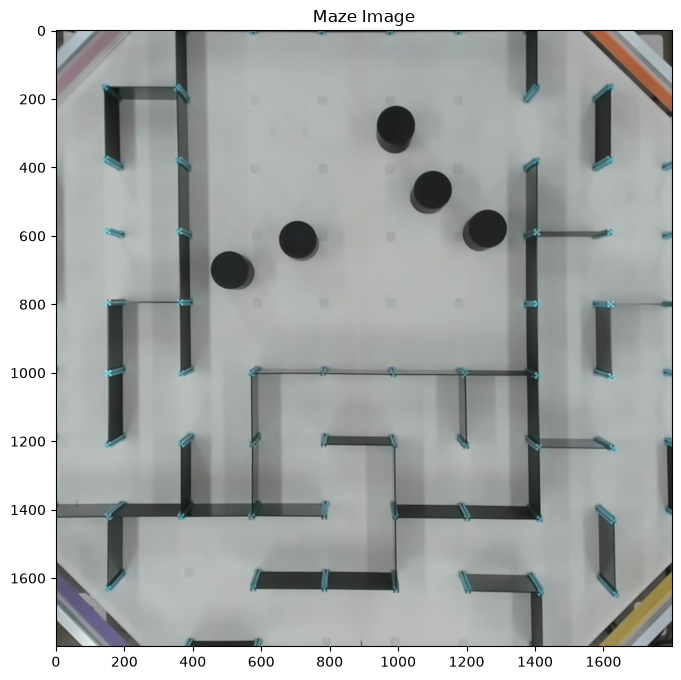

In [47]:
# Transform the maze image to a top-down view using the four corners coordinates.
source_points = np.float32(maze_corners)

output_width = 1800
output_height = 1800

destination_points = np.float32([
    [0, 0],
    [output_width - 1, 0],
    [output_width - 1, output_height - 1],
    [0, output_height - 1],
])

H = cv2.getPerspectiveTransform(source_points, destination_points)

rectified_bgr = cv2.warpPerspective(image, H, (output_width, output_height))

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(rectified_bgr, cv2.COLOR_BGR2RGB))
plt.title("Maze Image")
plt.show()

## 5. Wall Mask

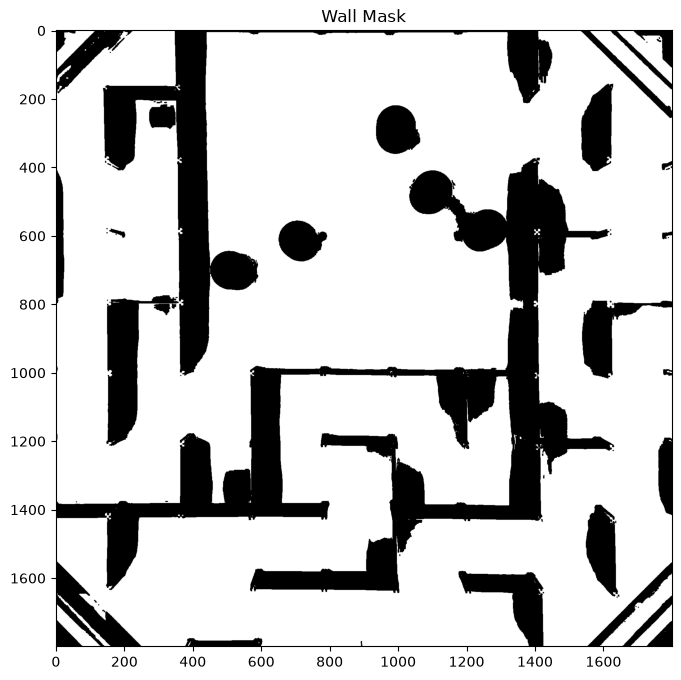

In [48]:
# Create a wall mask by thresholding the rectified maze image in HSV color space.

grid_hsv = cv2.cvtColor(rectified_bgr, cv2.COLOR_BGR2HSV)

lower_hsv = np.array([0, 0, 150])       # Increase V to increase mask affect
upper_hsv = np.array([180, 255, 255])

# White means bright floor
wall_mask = cv2.inRange(grid_hsv, lower_hsv, upper_hsv)

kernel = np.ones((3, 3), np.uint8)

# Connect small gaps without excessively thickening everything
wall_mask = cv2.morphologyEx(wall_mask, cv2.MORPH_CLOSE, kernel, iterations=1)

plt.figure(figsize=(8, 8))
plt.imshow(wall_mask, cmap="gray")
plt.title("Wall Mask")
plt.show()

## 6. Wall Detection

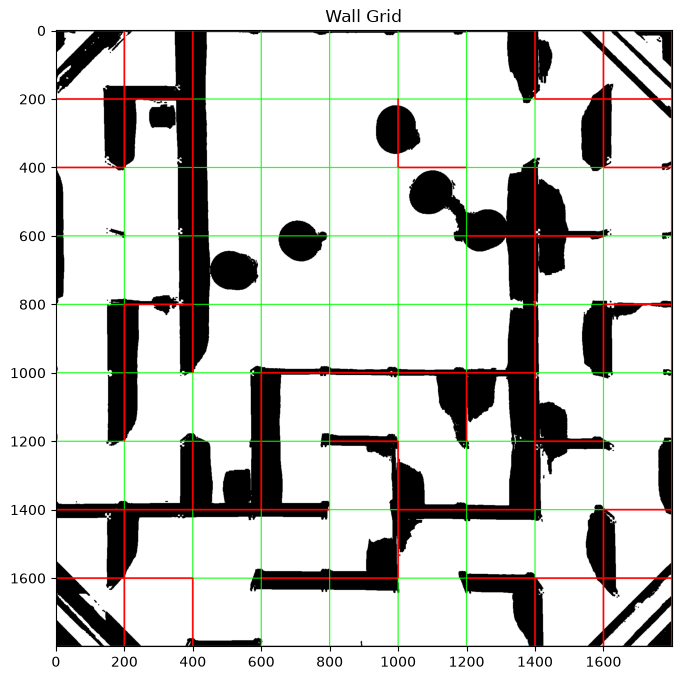

In [49]:
# HELPER: Return true if a black line exists between two points in the image
def black_line_exists(image, x1, y1, x2, y2, horizontal, width):
    img_h, img_w = image.shape[:2]
    half = width // 2

    def line_all_black(ax1, ay1, ax2, ay2):
        length = int(max(abs(ax2 - ax1), abs(ay2 - ay1)))
        if length == 0:
            return np.all(image[int(ay1), int(ax1)] < 128)
        for i in range(length + 1):
            t = i / length
            x = int(round(ax1 + t * (ax2 - ax1)))
            y = int(round(ay1 + t * (ay2 - ay1)))
            if not np.all(image[y, x] == 0):  # pixel isn't black -> line broken
                return False
        return True

    for offset in range(-half, half + 1):
        if horizontal:
            ox1, oy1 = x1, y1 + offset
            ox2, oy2 = x2, y2 + offset
        else:
            ox1, oy1 = x1 + offset, y1
            ox2, oy2 = x2 + offset, y2

        # Skip offset lines that fall outside the image
        if not (0 <= ox1 < img_w and 0 <= ox2 < img_w and
                0 <= oy1 < img_h and 0 <= oy2 < img_h):
            continue

        if line_all_black(ox1, oy1, ox2, oy2):
            return True

    return False

# Compute the cell dimensions in pixels based on the wall mask size and the number of rows and columns.
height, width = wall_mask.shape

cell_h = height / ROWS
cell_w = width / COLS

SAMPLE_THICKNESS = 80   # Band thickness to scan perpendicular to each boundary (half either side)
SAMPLE_MARGIN = 0.25    # Exclude 25% from each end of the cell boundary

# Helper: Manually block a cell by setting all four walls to True.
def block_cell(row, col):
    # Top and bottom walls
    horizontal_walls[row, col] = True
    horizontal_walls[row + 1, col] = True

    # Left and right walls
    vertical_walls[row, col] = True
    vertical_walls[row, col + 1] = True

# --- Horizontal boundaries: (ROWS + 1) x COLS ---
horizontal_walls = np.zeros((ROWS + 1, COLS), dtype=bool)

for r in range(ROWS + 1):
    # Expected y-coordinate of the horizontal boundary
    y_boundary = int(r * cell_h)

    for c in range(COLS):
        # Force the top and bottom outer boundaries to be walls
        if r == 0 or r == ROWS:
            horizontal_walls[r, c] = True
            continue

        # Endpoints of the segment along the boundary (middle portion of the cell width)
        x1 = int((c + SAMPLE_MARGIN) * cell_w)
        x2 = int((c + 1 - SAMPLE_MARGIN) * cell_w)

        horizontal_walls[r, c] = black_line_exists(
            wall_mask, x1, y_boundary, x2, y_boundary,
            horizontal=True, width=SAMPLE_THICKNESS
        )

# --- Vertical boundaries: ROWS x (COLS + 1) ---
vertical_walls = np.zeros((ROWS, COLS + 1), dtype=bool)

for r in range(ROWS):
    for c in range(COLS + 1):
        # Force the left and right outer boundaries to be walls
        if c == 0 or c == COLS:
            vertical_walls[r, c] = True
            continue
        
        # Expected x-coordinate of the vertical boundary
        x_boundary = int(c * cell_w)

        # Endpoints of the segment along the boundary (middle portion of the cell height)
        y1 = int((r + SAMPLE_MARGIN) * cell_h)
        y2 = int((r + 1 - SAMPLE_MARGIN) * cell_h)

        vertical_walls[r, c] = black_line_exists(
            wall_mask, x_boundary, y1, x_boundary, y2,
            horizontal=False, width=SAMPLE_THICKNESS
        )

# Block the corner cells
block_cell(0, 0) # Top-left corner cell
block_cell(0, 1) # Node 1 cell
block_cell(1, 0) # Node 9 cell
block_cell(0, COLS - 1) # Top-right corner cell
block_cell(0, COLS - 2) # Node 7 cell
block_cell(1, COLS - 1) # Node 17 cell
block_cell(ROWS - 1, 0) # Bottom-left corner cell
block_cell(ROWS - 2, 0) # Node 63 cell
block_cell(ROWS - 1, 1) # Node 73 cell
block_cell(ROWS - 1, COLS - 1) # Bottom-right corner cell
block_cell(ROWS - 2, COLS - 1) # Node 71 cell
block_cell(ROWS - 1, COLS - 2) # Node 79 cell

# Display detected walls and open boundaries ----------------------------------

# Convert the grayscale mask to BGR so coloured lines can be drawn
wall_grid = cv2.cvtColor(wall_mask, cv2.COLOR_GRAY2BGR)

# Draw horizontal boundaries
for r in range(ROWS + 1):
    for c in range(COLS):

        x1 = int(c * cell_w)
        x2 = int((c + 1) * cell_w)
        y = int(r * cell_h)

        colour, thickness = (RED, 4) if horizontal_walls[r, c] else (GREEN, 2)
        cv2.line(wall_grid, (x1, y), (x2, y), colour, thickness)

# Draw vertical boundaries
for r in range(ROWS):
    for c in range(COLS + 1):

        x = int(c * cell_w)
        y1 = int(r * cell_h)
        y2 = int((r + 1) * cell_h)

        colour, thickness = (RED, 4) if vertical_walls[r, c] else (GREEN, 2)
        cv2.line(wall_grid, (x, y1), (x, y2), colour, thickness)

# Display the result
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(wall_grid, cv2.COLOR_BGR2RGB))
plt.title("Wall Grid")
plt.show()

## 7. Maze Graph

In [50]:
# Graph class
class Node:
    def __init__(self, node_id, x, y):
        self.id = node_id
        self.x = x
        self.y = y
    
    def get_point(self):
        return (self.x, self.y)
    
    def get_ID(self):
        return self.id

class Graph:
    def __init__(self):
        self.nodes = {}
        self.edges = {}

    def add_node(self, node_id, x, y):
        self.nodes[node_id] = Node(node_id, x, y)
        self.edges[node_id] = {}

    def add_edge(self, node_id1, node_id2, weight):
        if node_id1 not in self.nodes or node_id2 not in self.nodes:
            return
        self.edges[node_id1][node_id2] = weight
        self.edges[node_id2][node_id1] = weight

    def remove_edge(self, node_id1, node_id2):
        if node_id1 in self.edges:
            self.edges[node_id1].pop(node_id2, None)
        if node_id2 in self.edges:
            self.edges[node_id2].pop(node_id1, None)
    
    def get_nodes(self):
        return self.nodes
    
    def get_edge_weight(self, node_id1, node_id2):
        if node_id1 not in self.edges:
            return None
        return self.edges[node_id1].get(node_id2)

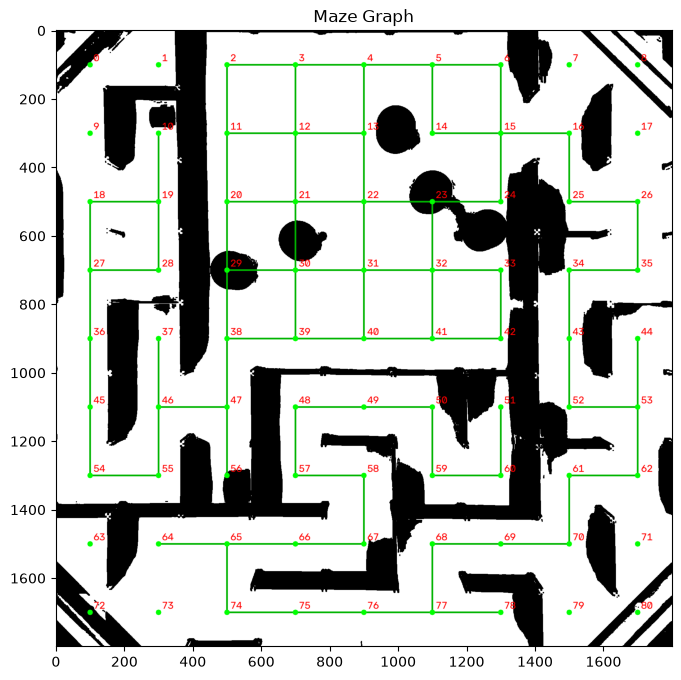

In [51]:
maze_graph = Graph()

for row in range(ROWS):
    for col in range(COLS):

        node_id = row * COLS + col

        # Position at the centre of the cell
        x = int((col + 0.5) * cell_w)
        y = int((row + 0.5) * cell_h)

        maze_graph.add_node(node_id, x, y)

for row in range(ROWS):
    for col in range(COLS):

        current_id = row * COLS + col

        # Check the cell to the right
        if col < COLS - 1:

            right_wall = vertical_walls[row, col + 1]

            if not right_wall: # No wall to the right, connect the two cells
                right_id = current_id + 1
                maze_graph.add_edge(current_id, right_id, 1)

        # Check the cell below
        if row < ROWS - 1:

            bottom_wall = horizontal_walls[row + 1, col]

            if not bottom_wall: # No wall below, connect the two cells
                bottom_id = current_id + COLS
                maze_graph.add_edge(current_id, bottom_id, 1)

# Draw all graph edges
graph_overlay = cv2.cvtColor(wall_mask, cv2.COLOR_GRAY2BGR)

for node_id_1, neighbours in maze_graph.edges.items():
    point_1 = maze_graph.get_nodes()[node_id_1].get_point()
    for node_id_2 in neighbours:
        if node_id_1 < node_id_2:
            point_2 = maze_graph.get_nodes()[node_id_2].get_point()
            cv2.line(graph_overlay, point_1, point_2, (0, 180, 0), 4)

# Draw all graph nodes
for node in maze_graph.get_nodes().values():
    cv2.circle(graph_overlay, node.get_point(), 8, GREEN, -1)
    cv2.putText(graph_overlay, str(node.get_ID()),
        (node.get_point()[0] + 10, node.get_point()[1] - 10),
        cv2.FONT_HERSHEY_SIMPLEX, 1, RED, 1)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(graph_overlay, cv2.COLOR_BGR2RGB))
plt.title("Maze Graph")
plt.show()

## 8. BFS Implementation

In [52]:
# Implements BFS

def bfs(graph, start_node_id, end_node_id):
    path = []

    if start_node_id not in graph.get_nodes() or end_node_id not in graph.get_nodes():
        return path

    q = deque()
    cost = {start_node_id: 0}
    parent = {start_node_id: -1}

    q.append(start_node_id)

    while q:
        currNode = q.popleft()

        if currNode == end_node_id:
            break  # Stop if we reach the end node

        for adj in graph.edges[currNode]:
            if adj not in cost:  # Not visited
                cost[adj] = cost[currNode] + 1
                parent[adj] = currNode
                q.append(adj)

    # If the end node is unreachable
    if end_node_id not in cost:
        return path

    # Reconstruct the shortest path
    currNode = end_node_id
    while currNode != -1:
        path.append(currNode)
        if currNode == start_node_id:
            break
        currNode = parent[currNode]

    path.reverse()
    return path

## 9. Path Generation & Visualisation

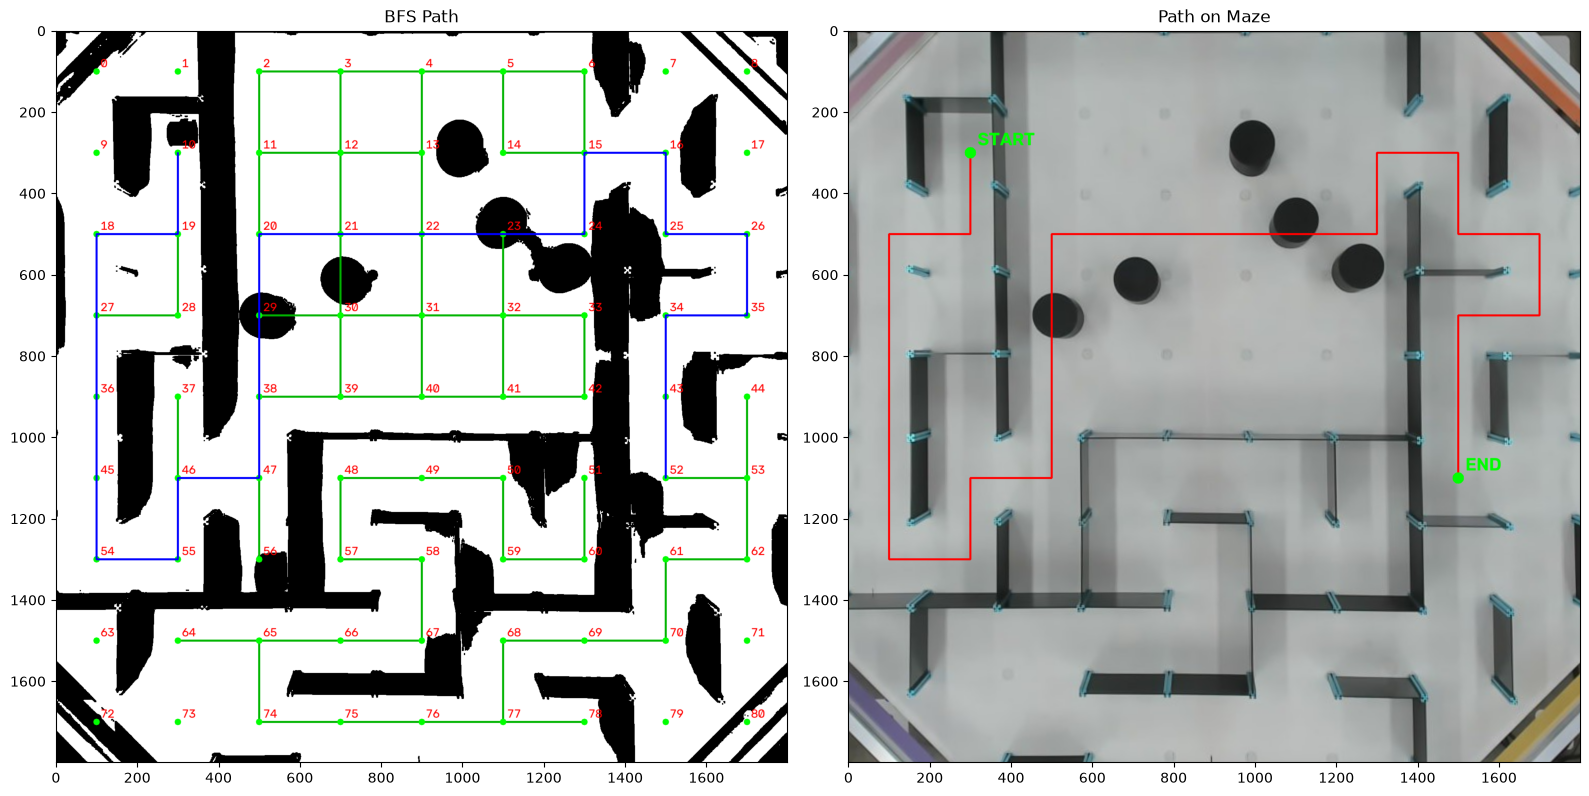

In [53]:
# Run BFS and draws the path through the maze (on graph with mask and rectified image))

path = bfs(maze_graph, BFS_START_NODE, BFS_END_NODE)

bfs_image = graph_overlay.copy()

for i in range(len(path) - 1):
    currNode = maze_graph.get_nodes()[path[i]].get_point()
    nextNode = maze_graph.get_nodes()[path[i + 1]].get_point()
    cv2.line(bfs_image, currNode, nextNode, (255, 0, 0), 4)

path_on_maze = rectified_bgr.copy()

start_node = maze_graph.get_nodes()[path[0]].get_point()
end_node = maze_graph.get_nodes()[path[-1]].get_point()

for i in range(len(path) - 1):
    currNode = maze_graph.get_nodes()[path[i]].get_point()
    nextNode = maze_graph.get_nodes()[path[i + 1]].get_point()
    cv2.line(path_on_maze, currNode, nextNode, (0, 0, 255), 4)

cv2.circle(path_on_maze, start_node, 14, GREEN, -1)
cv2.circle(path_on_maze, end_node, 14, GREEN, -1)

cv2.putText(path_on_maze,"START", (start_node[0] + 18, start_node[1] - 18),
            cv2.FONT_HERSHEY_SIMPLEX, 1.5, GREEN, 3)

cv2.putText(path_on_maze,"END", (end_node[0] + 18, end_node[1] - 18),
            cv2.FONT_HERSHEY_SIMPLEX, 1.5, GREEN, 3)

# Display the BFS path and the path on the maze side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(cv2.cvtColor(bfs_image, cv2.COLOR_BGR2RGB))
axes[0].set_title("BFS Path")

axes[1].imshow(cv2.cvtColor(path_on_maze, cv2.COLOR_BGR2RGB))
axes[1].set_title("Path on Maze")

plt.tight_layout()
plt.show()

## 10. Movement Commands

In [54]:
# Generate a string of movement commands from the BFS path.

def path_to_commands(path, start_direction):

    # Convert node IDs to (row, col)
    cell_path = [
        (node_id // COLS, node_id % COLS)
        for node_id in path
    ]

    directions = ["N", "E", "S", "W"]

    current_direction = start_direction
    commands = ""

    for i in range(len(cell_path) - 1):

        current_row, current_col = cell_path[i]
        next_row, next_col = cell_path[i + 1]

        # Determine required movement direction
        if next_row == current_row - 1:
            required_direction = "N"
        elif next_row == current_row + 1:
            required_direction = "S"
        elif next_col == current_col + 1:
            required_direction = "E"
        elif next_col == current_col - 1:
            required_direction = "W"

        # Determine required turn
        current_index = directions.index(current_direction)
        required_index = directions.index(required_direction)

        turn = (required_index - current_index) % 4
        if turn == 1:
            commands += "r"
        elif turn == 2:
            commands += "rr"
        elif turn == 3:
            commands += "l"
        commands += "f"
        current_direction = required_direction

    return commands

commands = path_to_commands(path, start_direction)

# Prints the path string
print("-" * (27 + len(commands)))
print(f"Full Path String:          {commands}")
print("-" * (27 + len(commands)))

-----------------------------------------------------------------
Full Path String:          frflfffflflfrflfffrfffflfrfrflfrfrflff
-----------------------------------------------------------------


## 14. All Images

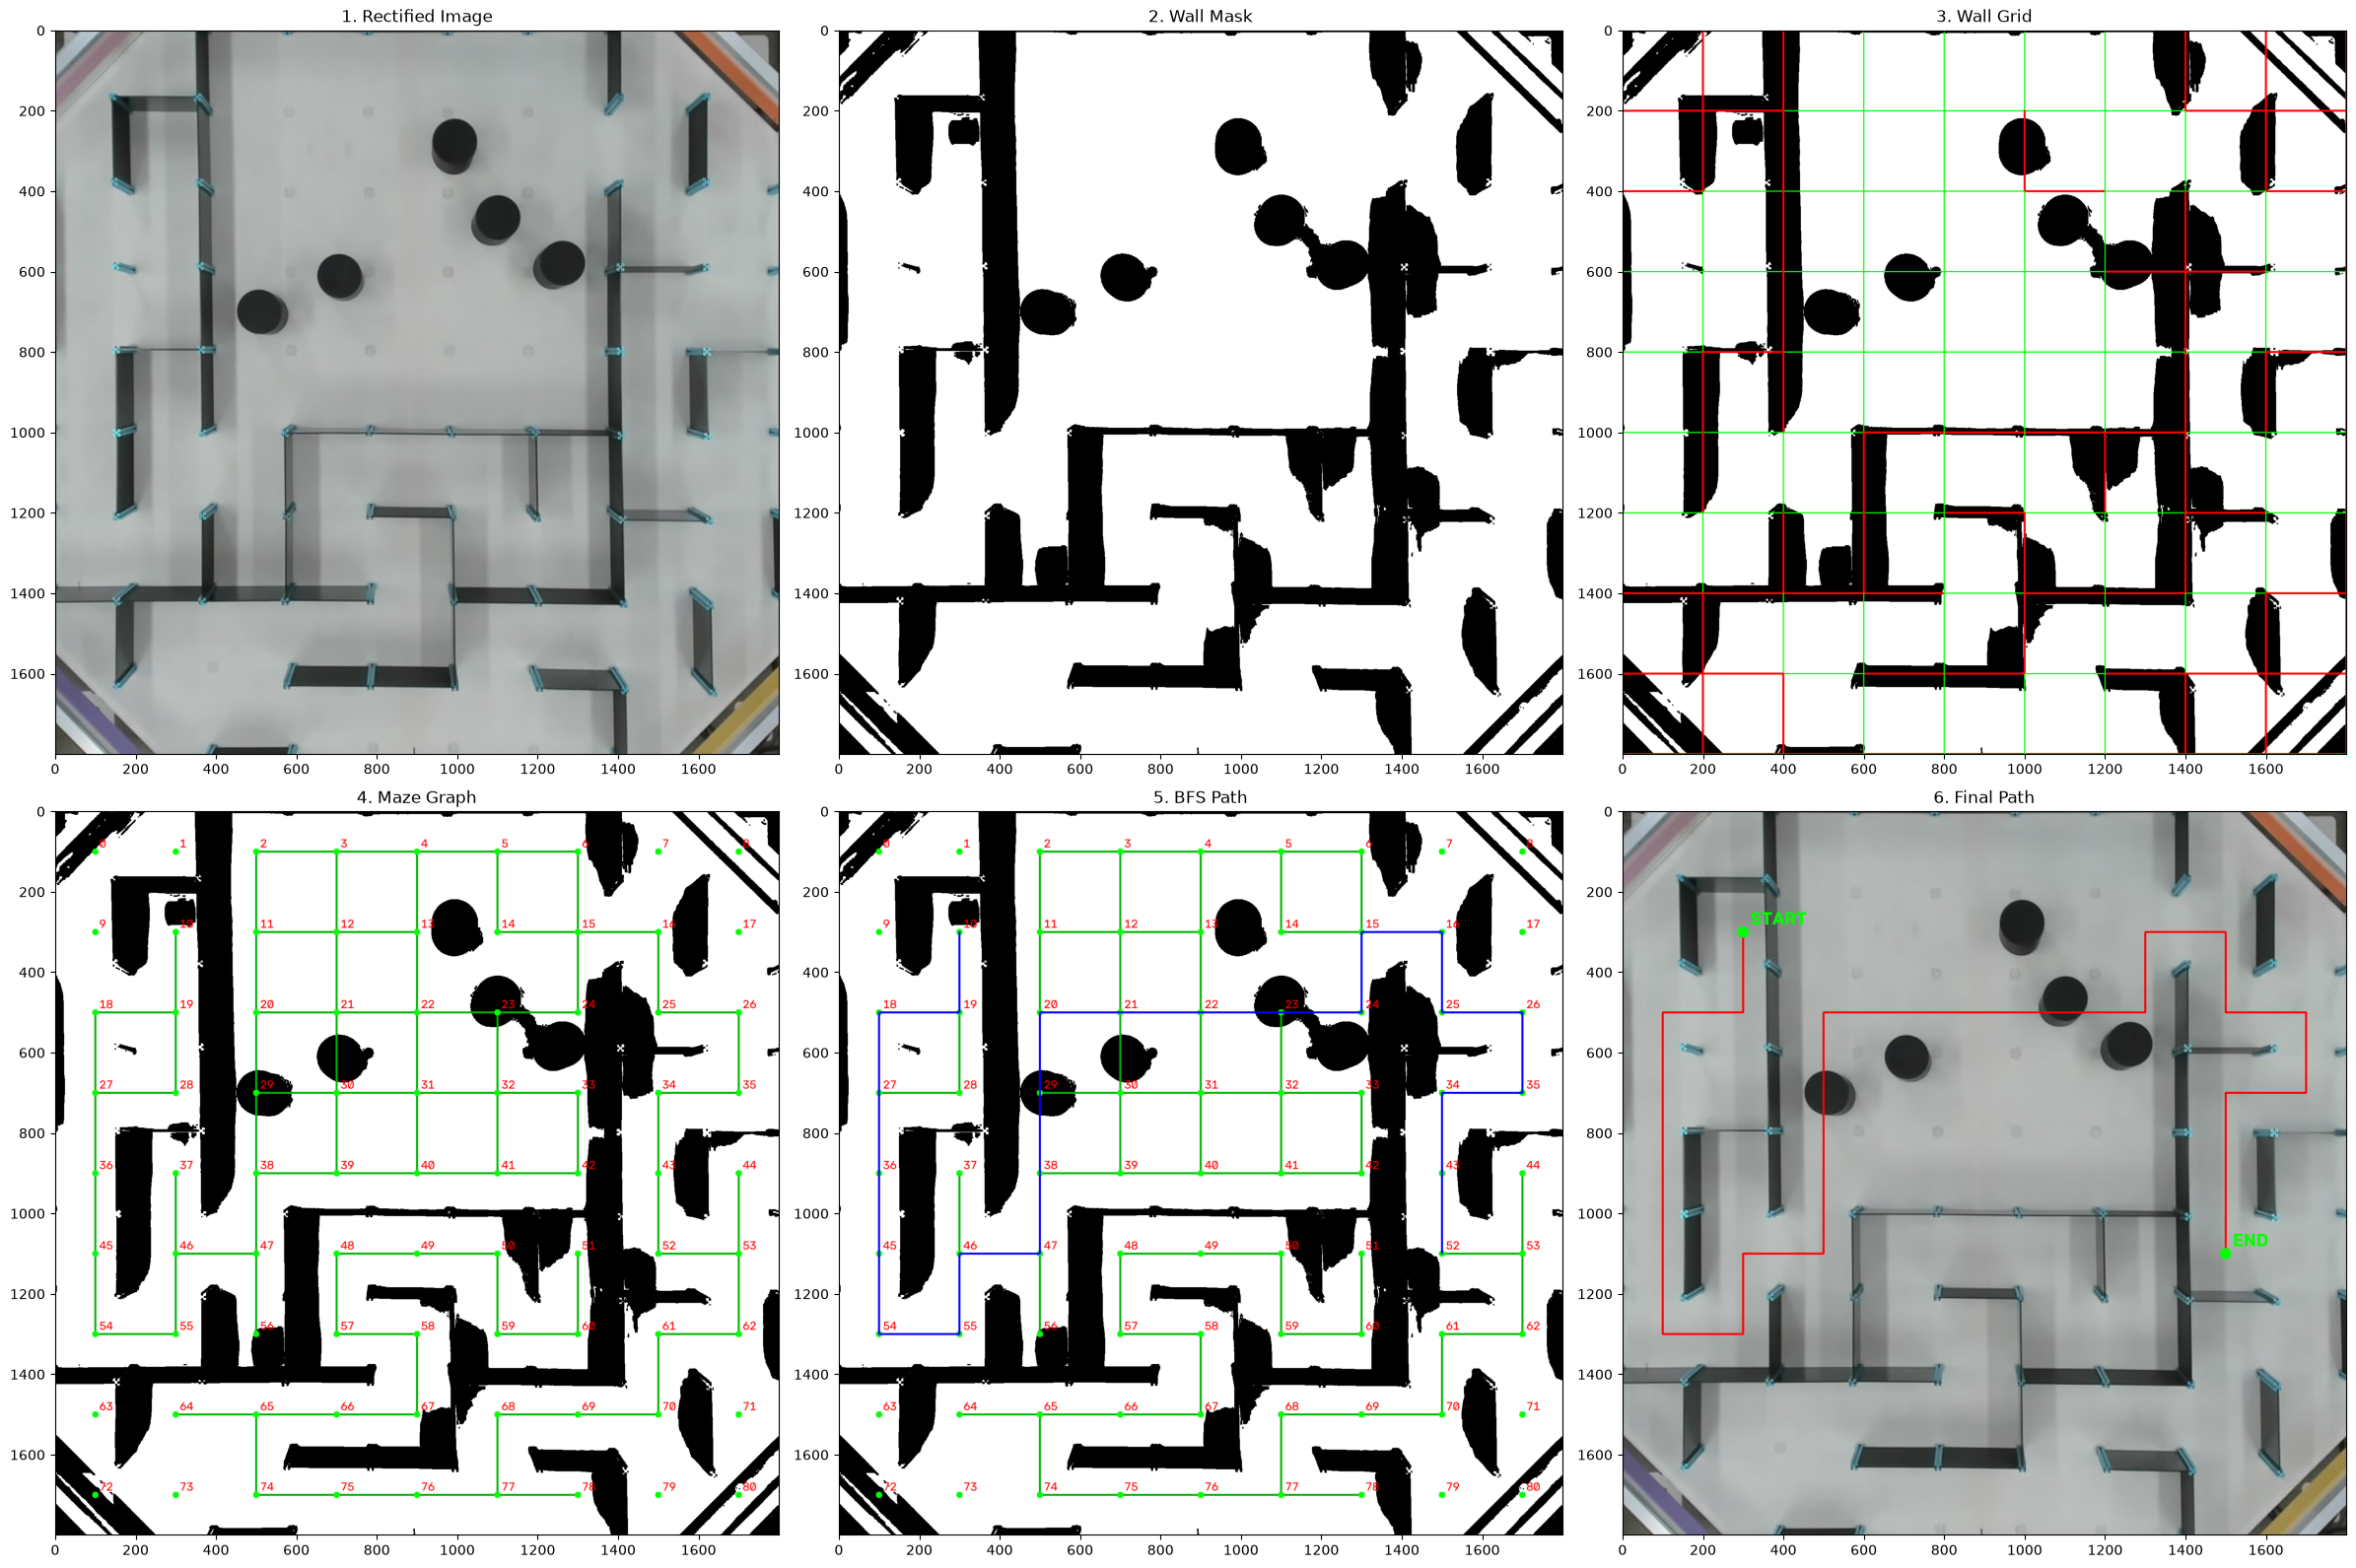

In [55]:
images = [rectified_bgr, wall_mask, wall_grid, graph_overlay, bfs_image, path_on_maze]
titles = ["1. Rectified Image", "2. Wall Mask", "3. Wall Grid", "4. Maze Graph", "5. BFS Path", "6. Final Path"]

fig, axes = plt.subplots(2, 3, figsize=(24, 16))

for ax, img, title in zip(axes.flat, images, titles):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)

plt.tight_layout()
plt.show()